In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count

from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import PCA

import matplotlib.pyplot as plt

In [0]:
spark = SparkSession.builder.appName("PCA_").getOrCreate()

In [0]:
df = spark.read.csv(
    "/Volumes/workspace/default/assignment_data/adult.csv",
    header=True,
    inferSchema=True
)
display(df.limit(5))

age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [0]:
# Rename the column because pyspark consider "." as new file inside the outer one so replacing it as "_"

df = df.toDF(*[
    c.replace(".", "_")
     .replace("-", "_")
     .replace(" ", "_")
    for c in df.columns
])

## Handling missing values and duplicate values

In [0]:
df = df.filter(col("workclass") != "?")
df = df.filter(col("occupation") != "?")
df = df.filter(col("native_country") != "?")

df = df.dropDuplicates()

## Feature Engineering

In [0]:
categorical_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

for column in categorical_cols:

    indexer = StringIndexer(
        inputCol=column,
        outputCol=column+"_index",
        handleInvalid="keep"
    )

    df = indexer.fit(df).transform(df)

## Feature Scaling

In [0]:
feature_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "workclass_index",
    "education_index",
    "marital_status_index",
    "occupation_index",
    "relationship_index",
    "race_index",
    "sex_index",
    "native_country_index"
]


assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

df = assembler.transform(df)

In [0]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

scaler_model = scaler.fit(df)

df = scaler_model.transform(df)

## Apply PCA

In [0]:
pca = PCA(
    k=5,
    inputCol="scaled_features",
    outputCol="pca_features"
)

pca_model = pca.fit(df)

df = pca_model.transform(df)

display(df.select("pca_features").limit(5))

pca_features
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-1.9595815616602827"",""-3.9677848571072545"",""1.3005237532111669"",""0.46817175353066376"",""1.55755446983258""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.1010788955838754"",""-5.150702472203623"",""3.347251447693141"",""4.071873657015121"",""1.6648595641099595""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-2.1987339250678843"",""-3.223874387264222"",""2.1636283955270534"",""2.7486833925515524"",""2.599221428741603""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-3.8365483097909827"",""-4.8114899283612615"",""6.702444427809626"",""-0.3464562380667713"",""1.9990274751647898""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-4.006156679324494"",""-4.371436368193667"",""2.499915285844981"",""0.36964032223699217"",""-0.10121835967154169""]}"


## Compare Original vs Reduced Dimensions

In [0]:
print("Original Number of Features:", len(feature_columns))
print("Reduced Number of Features:", 5)

Original Number of Features: 14
Reduced Number of Features: 5


## Explained Variance

In [0]:
print("Explained Variance:")

for i, variance in enumerate(pca_model.explainedVariance):
    print(f"Principal Component {i+1}: {variance:.4f}")

Explained Variance:
Principal Component 1: 0.1590
Principal Component 2: 0.1047
Principal Component 3: 0.0895
Principal Component 4: 0.0797
Principal Component 5: 0.0752


## Total Explained Variance

In [0]:
total_variance = float(sum(pca_model.explainedVariance))

print("Total Explained Variance:", round(total_variance,4))

Total Explained Variance: 0.5081


## Convert PCA output into 2 columns

In [0]:
# Extracted the first two principal components (PC1 and PC2) from the PCA output for visualization.

from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

get_pc1 = udf(lambda x: float(x[0]), DoubleType())
get_pc2 = udf(lambda x: float(x[1]), DoubleType())

df = df.withColumn("PC1", get_pc1("pca_features"))
df = df.withColumn("PC2", get_pc2("pca_features"))

display(df.select("PC1", "PC2").limit(5))

PC1,PC2
-1.9595815616602827,-3.9677848571072545
-0.1010788955838754,-5.150702472203623
-2.1987339250678843,-3.223874387264222
-3.8365483097909827,-4.8114899283612615
-4.006156679324494,-4.371436368193667


## Scatter Plot

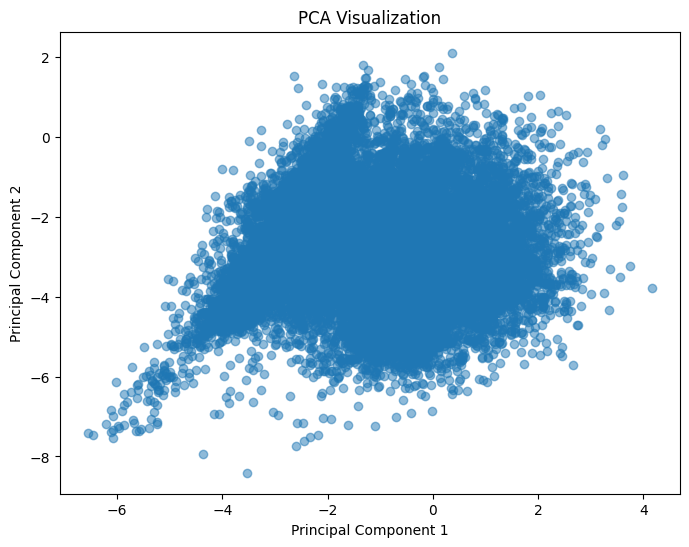

In [0]:
pdf = df.select("PC1", "PC2").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pdf["PC1"], pdf["PC2"], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()